SHAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [ ]:
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_PATH = "/kaggle/input/datasets/vadimcvbnqq/data-1/train_2.csv"
# DATA_PATH = "train_2.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [4]:
df.columns = df.columns.str.replace(',', '', regex=False)
df.columns

Index(['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия категориальный',
       'Торговая площадь категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший в час', 'Трафик авто в час',
       'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс',
       'Флаг алкогольной лицензии', 'РТО'],
      dtype='object')

In [5]:
df[(df["Год"] == 2022)]

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,Дата открытия категориальный,Торговая площадь категориальный,Населенный пункт,Регион,Численность населения,Количество домохозяйств,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО


In [6]:
df[(df["Год"] == 2023) & (df["Месяц"] == 1)].head(1)


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,Дата открытия категориальный,Торговая площадь категориальный,Населенный пункт,Регион,Численность населения,Количество домохозяйств,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22


rolling_mean

# Инфляция 
------------------------------------------------------------------------------------------------

Логика следующая:

1. Посчитаем медианную выручку по всей сети для каждого месяца. Ее рост и будет идеальным отражением инфляции + масштаба рынка.

2. **Дефлируем трейн:**  
   Разделим историческое РТО на этот индекс. Модель будет учиться предсказывать «чистые физические объемы продаж» в ценах базового месяца.

3. **Инфлируем тест:**  
   При финальном прогнозе на Март 2025 года мы возьмем предсказание модели и умножим его на спрогнозированный индекс инфляции Марта.

In [8]:
df_macro = df[df['РТО'] > 0].copy()
macro = df_macro.groupby(['Год', 'Месяц'])['РТО'].median().reset_index()
macro = macro.sort_values(['Год', 'Месяц']).reset_index(drop=True)
macro

,Год,Месяц,РТО
0,2023,1,61536441.58
1,2023,2,59697426.57
2,2023,3,67368328.13
3,2023,4,68210235.48
4,2023,5,72007592.97
5,2023,6,70882433.96
6,2023,7,73209133.39
7,2023,8,72461796.10
8,2023,9,69107223.21
9,2023,10,71046935.37


In [9]:
base_rto = macro['РТО'].iloc[0]
macro['inflation_idx'] = macro['РТО'] / base_rto
macro

,Год,Месяц,РТО,inflation_idx
0,2023,1,61536441.58,1.000000
1,2023,2,59697426.57,0.970115
2,2023,3,67368328.13,1.094771
3,2023,4,68210235.48,1.108453
4,2023,5,72007592.97,1.170162
5,2023,6,70882433.96,1.151877
6,2023,7,73209133.39,1.189687
7,2023,8,72461796.10,1.177543
8,2023,9,69107223.21,1.123029
9,2023,10,71046935.37,1.154551


In [10]:
inflation_dict = dict(zip(zip(macro['Год'], macro['Месяц']), macro['inflation_idx']))
inflation_dict

{(2023, 1): 1.0,
 (2023, 2): 0.9701150251333724,
 (2023, 3): 1.0947712672403764,
 (2023, 4): 1.1084527107620252,
 (2023, 5): 1.1701617955335792,
 (2023, 6): 1.1518773614468722,
 (2023, 7): 1.1896874682756071,
 (2023, 8): 1.177542838673838,
 (2023, 9): 1.123029239839253,
 (2023, 10): 1.1545505971065284,
 (2023, 11): 1.1346802921521808,
 (2023, 12): 1.3404341185826494,
 (2024, 1): 1.1336977277001656,
 (2024, 2): 1.1581444864235193,
 (2024, 3): 1.2905399183142043,
 (2024, 4): 1.2753149307142633,
 (2024, 5): 1.3531127668757217,
 (2024, 6): 1.338432589946323,
 (2024, 7): 1.3808713339319483,
 (2024, 8): 1.3342337585975181,
 (2024, 9): 1.2655862016127972,
 (2024, 10): 1.3088341743858112,
 (2024, 11): 1.2961932219675807,
 (2024, 12): 1.5134765125949294,
 (2025, 1): 1.3051227818493563,
 (2025, 2): 1.2635794533051385}

In [11]:
feb_2025_idx = inflation_dict[(2025, 2)]
mar_2024_idx = inflation_dict[(2024, 3)]
feb_2024_idx = inflation_dict[(2024, 2)]

inflation_dict[(2025, 3)] = feb_2025_idx * (mar_2024_idx / feb_2024_idx)
inflation_dict

{(2023, 1): 1.0,
 (2023, 2): 0.9701150251333724,
 (2023, 3): 1.0947712672403764,
 (2023, 4): 1.1084527107620252,
 (2023, 5): 1.1701617955335792,
 (2023, 6): 1.1518773614468722,
 (2023, 7): 1.1896874682756071,
 (2023, 8): 1.177542838673838,
 (2023, 9): 1.123029239839253,
 (2023, 10): 1.1545505971065284,
 (2023, 11): 1.1346802921521808,
 (2023, 12): 1.3404341185826494,
 (2024, 1): 1.1336977277001656,
 (2024, 2): 1.1581444864235193,
 (2024, 3): 1.2905399183142043,
 (2024, 4): 1.2753149307142633,
 (2024, 5): 1.3531127668757217,
 (2024, 6): 1.338432589946323,
 (2024, 7): 1.3808713339319483,
 (2024, 8): 1.3342337585975181,
 (2024, 9): 1.2655862016127972,
 (2024, 10): 1.3088341743858112,
 (2024, 11): 1.2961932219675807,
 (2024, 12): 1.5134765125949294,
 (2025, 1): 1.3051227818493563,
 (2025, 2): 1.2635794533051385,
 (2025, 3): 1.408027878704241}

In [12]:
df['РТО_nominal'] = df['РТО']
df['inflation_multiplier'] = df.apply(lambda row: inflation_dict.get((int(row['Год']), int(row['Месяц'])), 1.0), axis=1)
df['РТО'] = df['РТО'] / df['inflation_multiplier']

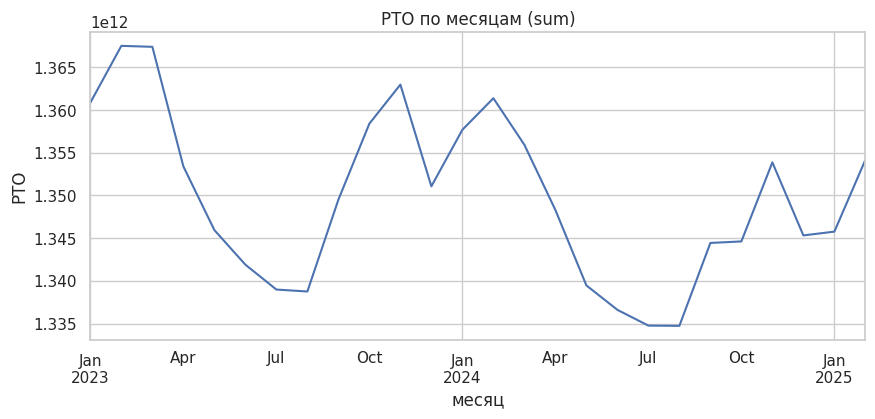

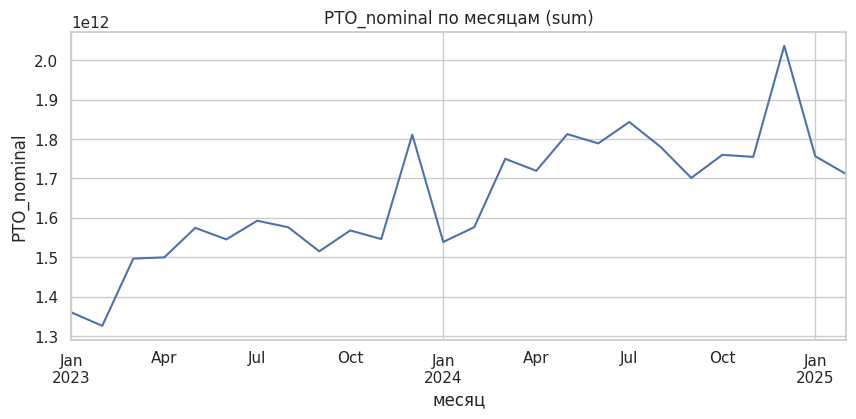

In [13]:
def plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum"):
    data = df[[year_col, month_col, target_col]].copy()
    data["_date"] = pd.to_datetime(
        data[year_col].astype(int).astype(str)
        + "-"
        + data[month_col].astype(int).astype(str).str.zfill(2)
        + "-01",
        errors="coerce",
    )
    data = data.dropna(subset=["_date"])

    grouped = data.groupby("_date")[target_col]
    if agg == "sum":
        series = grouped.sum()
    elif agg == "mean":
        series = grouped.mean()
    elif agg == "median":
        series = grouped.median()
    else:
        raise ValueError("agg должен быть: sum, mean или median")

    series = series.sort_index()
    ax = series.plot(figsize=(10, 4))
    ax.set_title(f"{target_col} по месяцам ({agg})")
    ax.set_xlabel("месяц")
    ax.set_ylabel(target_col)
    plt.show()
    return series
rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО", agg="sum")
rto_series = plot_target_series(df, year_col="Год", month_col="Месяц", target_col="РТО_nominal", agg="sum")

------------------------------------------------------------------------------------------------

In [ ]:
# df['РТО_nominal'] = df['РТО']
# df['inflation_multiplier'] = df.apply(lambda row: inflation_dict.get((int(row['Год']), int(row['Месяц'])), 1.0), axis=1)
# df['РТО'] = df['РТО'] / df['inflation_multiplier']


#

In [7]:
mean_cols = [c for c in df.columns if "Среднее" in str(c)]
mean_cols

['Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен']

Вместо expected_rto_base как фичи:

Используй его для смены таргета. Твой скор на ЛБ (89.65) может сильно вырасти, если ты перейдешь к моделированию остатков.

Пусть модель предсказывает не абсолютное РТО, а отклонение от expected_rto_base. То есть:
На трейне: target = РТО - expected_rto_base
На тесте: final_pred = model.predict(X) + expected_rto_base
Тогда бустинг сфокусируется не на угадывании масштаба магазина, а на предсказании чистой сезонности и тренда.

# Prepare

In [ ]:
import numpy as np
import pandas as pd
import calendar

def create_features_for_month(df, target_year, target_month, inflation_dict=None):
    """
    Функция собирает обучающие или тестовые признаки для конкретного целевого месяца.
    Все признаки, связанные с РТО, рассчитываются в логарифмической шкале (log1p).
    """
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
        'Дата открытия категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший в час', 'Трафик авто в час',
        'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)'
    ]
    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    
    target_time_value = target_year * 12 + target_month
    history_before_target = df[(df['Год'] * 12 + df['Месяц']) < target_time_value].copy()
    
    metrics_to_agg = [
        'Среднее количество промо товаров в чеке',
        'Среднее количество товаров в чеке',
        'Среднее количество отмен'
    ]

    shop_profile = history_before_target.groupby('new_id')[metrics_to_agg].mean().reset_index()

    cols_to_keep = ['new_id'] + metrics_to_agg
    base_df = base_df.merge(shop_profile[cols_to_keep], on='new_id', how='left')

    for col in cols_to_keep:
        if col != 'new_id':
            base_df[col] = base_df[col].fillna(0)
    
    base_df['Регион_Город'] = base_df['Регион'].astype(str) + "_" + base_df['Населенный пункт'].astype(str)
    
    def get_historical_rto(shift_months):
        total_months = target_year * 12 + (target_month - 1) - shift_months
        hist_y = total_months // 12
        hist_m = (total_months % 12) + 1
        
        hist_slice = df[(df['Год'] == hist_y) & (df['Месяц'] == hist_m)][['new_id', 'РТО']].copy()
        hist_slice[f'log_rto_lag_{shift_months}'] = np.log1p(hist_slice['РТО'])
        return hist_slice[['new_id', f'log_rto_lag_{shift_months}']]

    base_df = base_df.merge(get_historical_rto(1), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(2), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(6), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(12), on='new_id', how='left')

    base_df['log_rto_yoy_diff'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_12']
    base_df['reg_rto_yoy_trend'] = base_df.groupby('Регион')['log_rto_yoy_diff'].transform('mean')

    region_lag1_mean = base_df.groupby('Регион')['log_rto_lag_1'].transform('mean') 
    base_df['log_rto_vs_region'] = base_df['log_rto_lag_1'] - region_lag1_mean

    history_before_target['log_РТО'] = np.log1p(history_before_target['РТО'])
    
    def get_rolling_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')['log_РТО'].agg(['mean', 'std']).reset_index()
        agg_df.columns = [
            'new_id', 
            f'log_rto_roll_{window_months}m_mean', 
            f'log_rto_roll_{window_months}m_std'
        ]
        return agg_df
    
    base_df = base_df.merge(get_rolling_stats(3), on='new_id', how='left')
    base_df = base_df.merge(get_rolling_stats(6), on='new_id', how='left')
    
    roll_cols = [c for c in base_df.columns if 'log_rto_' in c]
    for c in roll_cols:
        base_df[c] = base_df[c].fillna(0)

    #(эквивалент деления: mean_3m / lag_1)
    base_df['log_rto_trend_3m'] = base_df['log_rto_roll_3m_mean'] - base_df['log_rto_lag_1']
    #(эквивалент деления: mean_6m / mean_3m)
    base_df['log_rto_trend_6m_vs_3m'] = base_df['log_rto_roll_6m_mean'] - base_df['log_rto_roll_3m_mean']
    base_df['log_rto_momentum'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_2']
    base_df.drop(columns=['log_rto_roll_3m_mean', 'log_rto_roll_6m_mean', 'log_rto_lag_2'], inplace=True)


    def get_rolling_other_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().reset_index()
        agg_df.columns = [
            'new_id', 
            f'promo_roll_{window_months}m_mean', 
            f'cancels_roll_{window_months}m_mean'
        ]
        return agg_df

    base_df = base_df.merge(get_rolling_other_stats(3), on='new_id', how='left')
    base_df['promo_roll_3m_mean'] = base_df['promo_roll_3m_mean'].fillna(0)
    base_df['cancels_roll_3m_mean'] = base_df['cancels_roll_3m_mean'].fillna(0)


    # Блок Отмен и Промо (Аномалии)
    base_df['cancels_anomaly'] = base_df['Среднее количество отмен'] - base_df['cancels_roll_3m_mean']
    base_df['promo_anomaly'] = base_df['Среднее количество промо товаров в чеке'] - base_df['promo_roll_3m_mean']
    base_df.drop(columns=['Среднее количество отмен', 'Среднее количество промо товаров в чеке'], inplace=True)

    
    rto_lag_1_linear = np.expm1(base_df['log_rto_lag_1'])
    base_df['log_rto_per_household'] = np.log1p(rto_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший в час'] / (base_df['Количество домохозяйств'] + 1)



    base_df['traffic_per_cashbox'] = base_df['Трафик пеший в час'] / (base_df['Количество касс'] + 1)
    base_df['competitor_density'] = base_df['Продуктовые магазины (500 м)'] / (base_df['Количество домохозяйств'] + 1)


    base_df['Месяц_сезон'] = int(target_month)

    store_age = history_before_target.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)

    
    abs_target_month = target_year * 12 + target_month - 1
    lag1_abs = abs_target_month - 1
    y_lag1 = lag1_abs // 12
    m_lag1 = (lag1_abs % 12) + 1

    def count_weekends(yr, mo):
        cal = calendar.Calendar()
        return sum(1 for d in cal.itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    target_weekends = count_weekends(target_year, target_month)
    lag1_weekends = count_weekends(y_lag1, m_lag1)
    
    base_df['weekends_ratio'] = target_weekends / (lag1_weekends + 1e-5)


    days_in_lag1_month = calendar.monthrange(y_lag1, m_lag1)[1]
    days_in_target_month = calendar.monthrange(target_year, target_month)[1] #base_df['days_in_target_month']
    # base_df['log_rto_lag_1_per_day'] = np.log1p(rto_lag_1_linear / days_in_lag1_month)
    base_df['expected_log_rto_base'] = np.log1p((rto_lag_1_linear / days_in_lag1_month) * days_in_target_month)
    base_df['month_days_ratio'] = days_in_target_month / days_in_lag1_month
    
    base_df['own_network_share'] = base_df['Пятерочки (500 м)'] / (base_df['Продуктовые магазины (500 м)'] + 1e-5)
    total_traffic = base_df['Трафик пеший в час'] + base_df['Трафик авто в час'] + 1e-5
    base_df['pedestrian_traffic_ratio'] = base_df['Трафик пеший в час'] / total_traffic
    base_df['poi_magnetism_index'] = (
        base_df['Маркетплейсы доставки постаматы (100 м)'] + 
        base_df['Медицинские уч. и аптеки (300 м)'] + 
        base_df['Школы (300 м)'] + 
        base_df['Остановки (300 м)'])
    base_df['reg_short_term_momentum'] = base_df.groupby('Регион')['log_rto_trend_3m'].transform('mean')


    # Какую часть чека в прошлом месяце составляли товары по акции?
    promo_share_lag1 = history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
        ].set_index('new_id')['Среднее количество промо товаров в чеке'] / (history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
    ].set_index('new_id')['Среднее количество товаров в чеке'] + 1e-5)
    
    base_df['promo_share_lag1'] = base_df['new_id'].map(promo_share_lag1).fillna(0)
    # #------------------------------------
    # #------------------------------------

    return base_df

In [90]:
import pandas as pd
import numpy as np

all_months = []

unique_periods = df[['Год', 'Месяц']].drop_duplicates().sort_values(by=['Год',  'Месяц'])

for _, row in unique_periods.iterrows():
    year = int(row['Год'])
    month = int(row[ 'Месяц'])
    
    X_m = create_features_for_month(df, year, month, inflation_dict)
    
    y_m = df[(df['Год'] == year) & (df[ 'Месяц'] == month)][['new_id', 'РТО']]
    # y_m = df[(df['Год'] == year) & (df['Месяц'] == month)][['new_id', 'РТО', 'РТО_nominal']]
    
    merged = X_m.merge(y_m, on='new_id', how='inner')
    merged['time_id'] = year * 100 + month # 202301, 202302 и т.д.
    
    all_months.append(merged)
    print(f"Собран {year}-{month:02d} | Строк: {len(merged)}")

master_df = pd.concat(all_months, ignore_index=True)

cat_features = [
    'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
    'Дата открытия категориальный', 'Регион_Город'#, 'Регион_Площадь', 'Регион_Алко'
]
for col in cat_features:
    master_df[col] = master_df[col].fillna('Missing').astype(str)

print(f"shape: {master_df.shape}")

Собран 2023-01 | Строк: 18657
Собран 2023-02 | Строк: 18657
Собран 2023-03 | Строк: 18657
Собран 2023-04 | Строк: 18657
Собран 2023-05 | Строк: 18657
Собран 2023-06 | Строк: 18657
Собран 2023-07 | Строк: 18657
Собран 2023-08 | Строк: 18657
Собран 2023-09 | Строк: 18657
Собран 2023-10 | Строк: 18657
Собран 2023-11 | Строк: 18657
Собран 2023-12 | Строк: 18657
Собран 2024-01 | Строк: 18657
Собран 2024-02 | Строк: 18657
Собран 2024-03 | Строк: 18657
Собран 2024-04 | Строк: 18657
Собран 2024-05 | Строк: 18657
Собран 2024-06 | Строк: 18657
Собран 2024-07 | Строк: 18657
Собран 2024-08 | Строк: 18657
Собран 2024-09 | Строк: 18657
Собран 2024-10 | Строк: 18657
Собран 2024-11 | Строк: 18657
Собран 2024-12 | Строк: 18657
Собран 2025-01 | Строк: 18657
Собран 2025-02 | Строк: 18657
shape: (485082, 48)


In [91]:
master_df.head(3)

,new_id,Регион,Населенный пункт,Торговая площадь категориальный,Дата открытия категориальный,Количество домохозяйств,Количество касс,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Среднее количество товаров в чеке,Регион_Город,log_rto_lag_1,log_rto_lag_6,log_rto_lag_12,log_rto_yoy_diff,reg_rto_yoy_trend,log_rto_vs_region,log_rto_roll_3m_std,log_rto_roll_6m_std,log_rto_trend_3m,log_rto_trend_6m_vs_3m,log_rto_momentum,promo_roll_3m_mean,cancels_roll_3m_mean,cancels_anomaly,promo_anomaly,log_rto_per_household,traffic_per_household,traffic_per_cashbox,competitor_density,Месяц_сезон,store_age_months,weekends_ratio,expected_log_rto_base,month_days_ratio,own_network_share,pedestrian_traffic_ratio,poi_magnetism_index,reg_short_term_momentum,promo_share_lag1,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,0.0,Ярославская обл_Ярославль г,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036547,12.545455,0.000794,1,0.0,0.999999,0.0,1.0,0.333332,0.654028,1,0.0,0.0,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,0.0,Челябинская обл_Магнитогорск г,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054414,15.888889,0.001522,1,0.0,0.999999,0.0,1.0,0.249999,0.244027,8,0.0,0.0,31205203.83,202301
2,2,Татарстан Респ,Казань г,Маленький,Средний по возрасту,10652,8,176,335,1,8,0,4,9,6,0.0,Татарстан Респ_Казань г,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016521,19.555556,0.000845,1,0.0,0.999999,0.0,1.0,0.666666,0.344423,13,0.0,0.0,59621632.75,202301


In [92]:
ts = master_df['time_id'].unique()
ts, len(ts)

(array([202301, 202302, 202303, 202304, 202305, 202306, 202307, 202308,
        202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404,
        202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412,
        202501, 202502]),
 26)

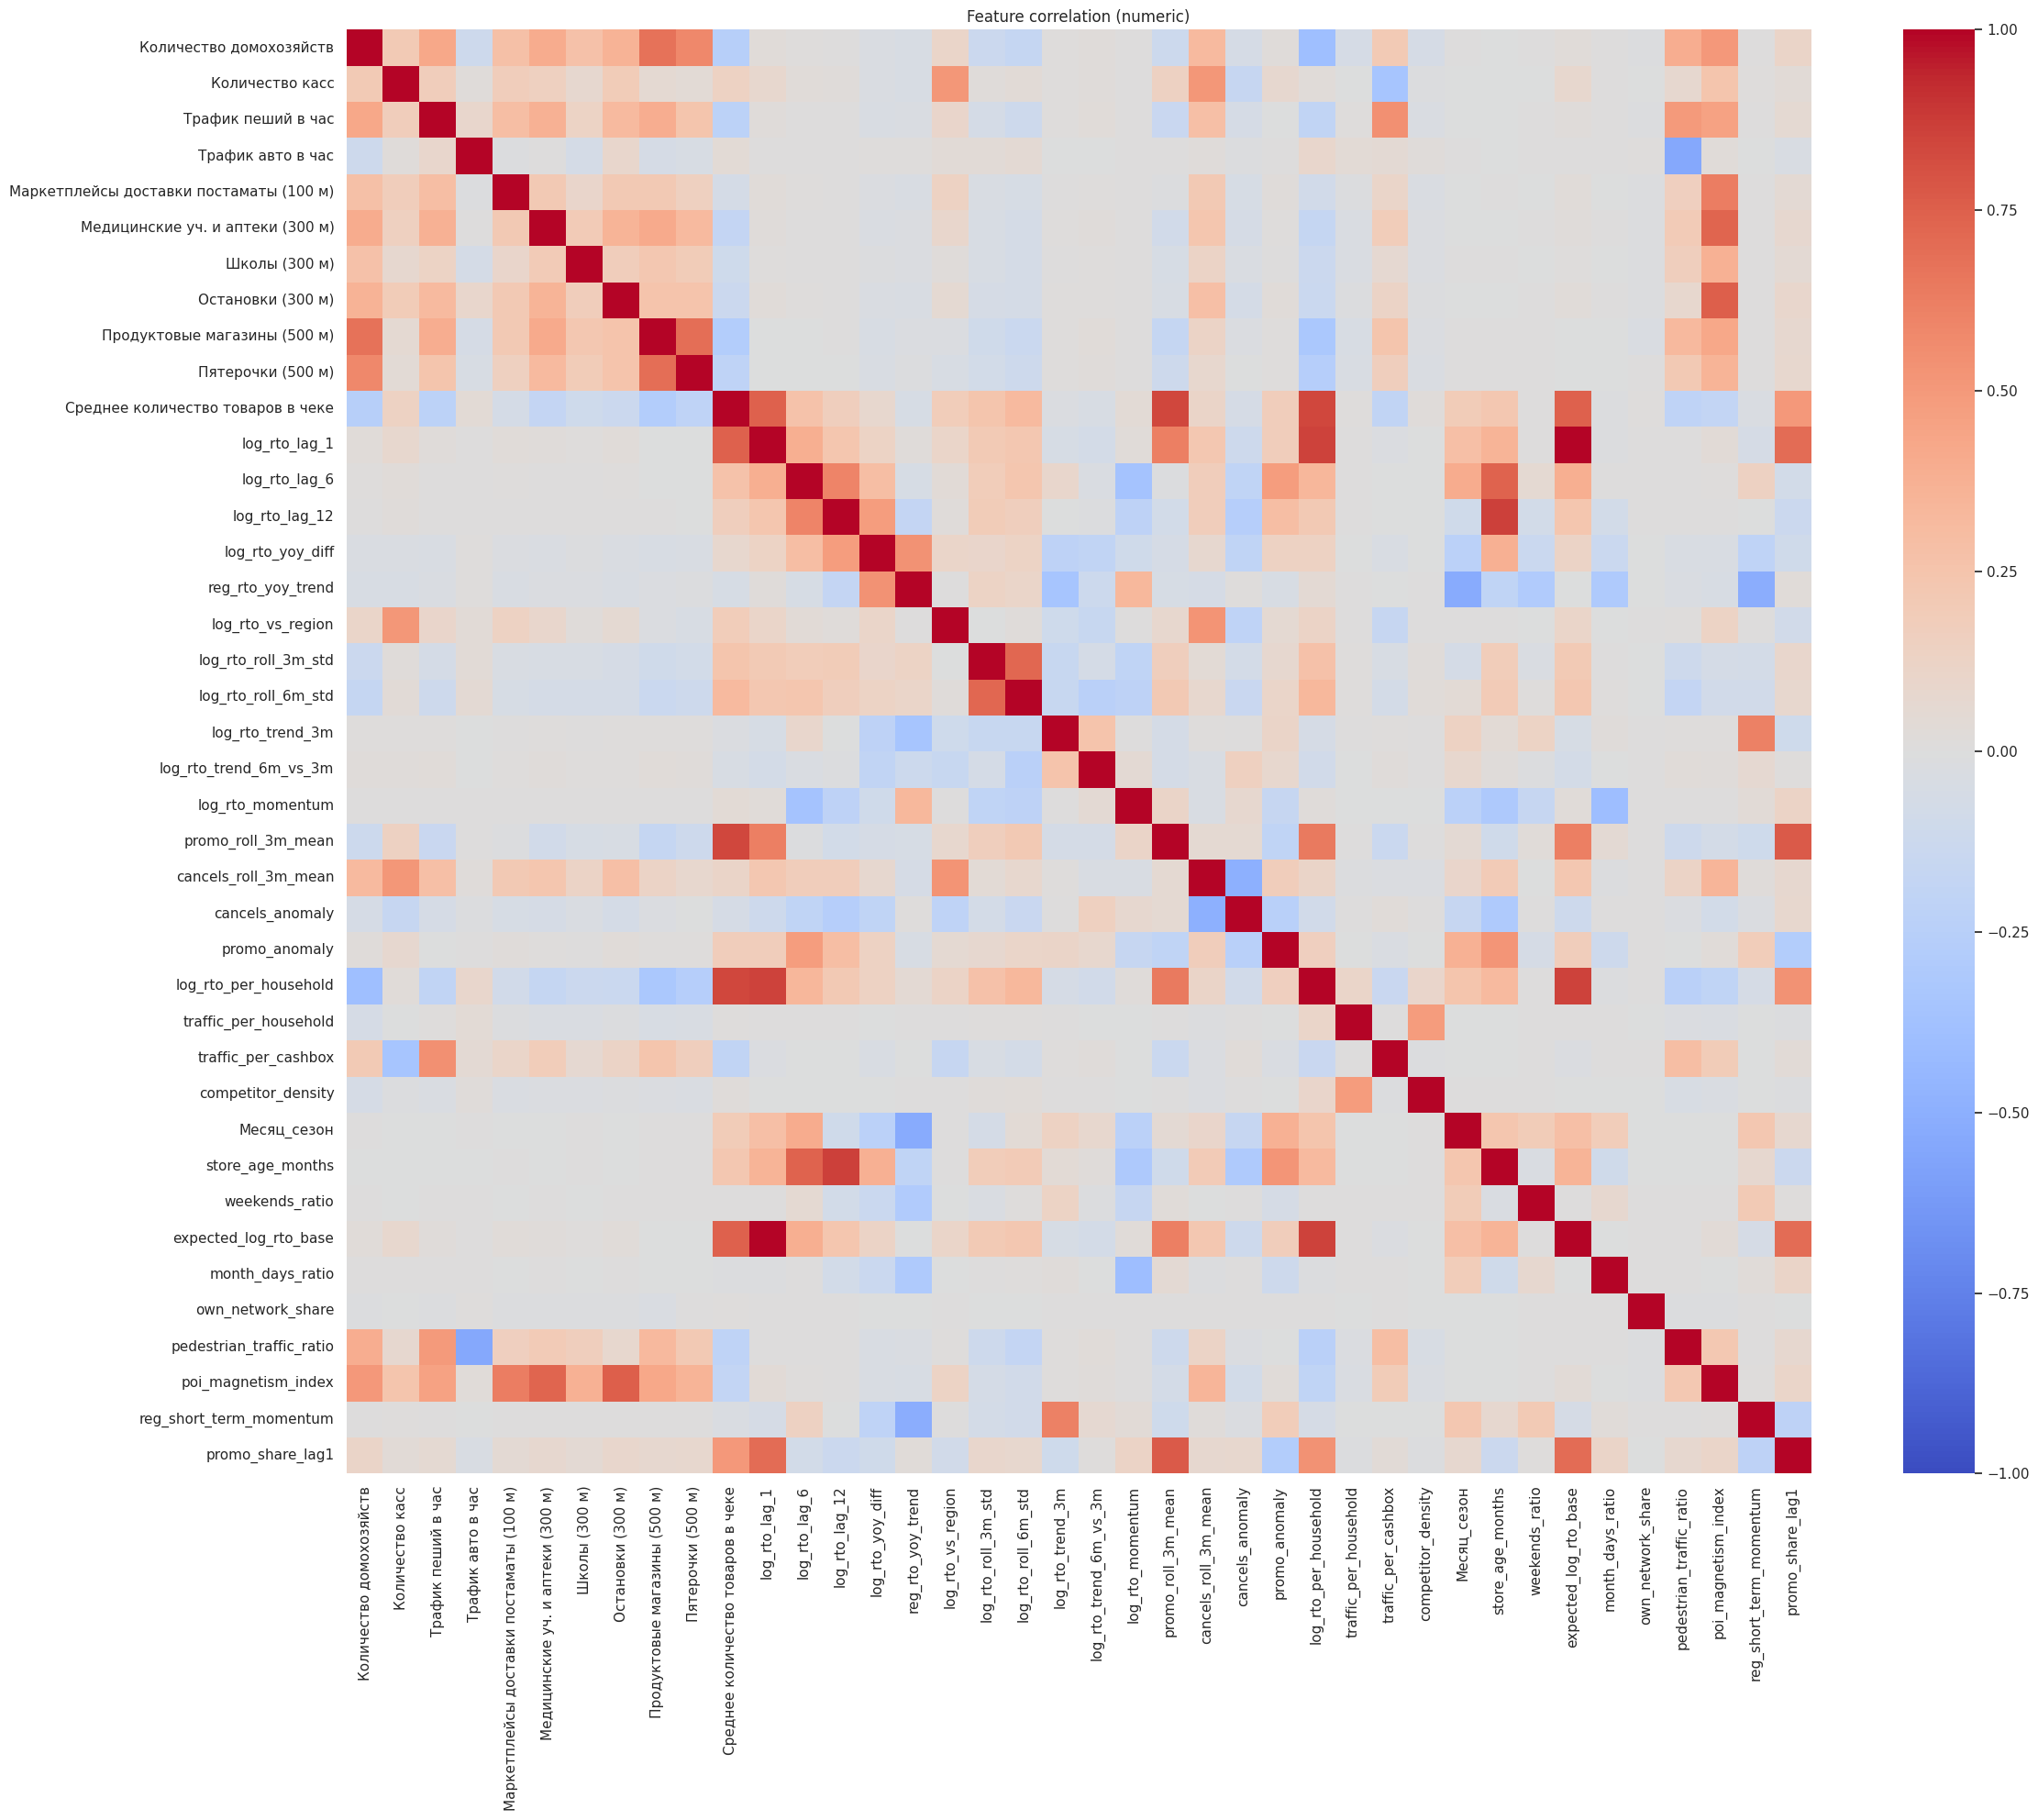

,feature_1,feature_2,corr
0,log_rto_lag_1,expected_log_rto_base,0.999912
1,log_rto_lag_12,store_age_months,0.865074
2,log_rto_lag_1,log_rto_per_household,0.857630
3,log_rto_per_household,expected_log_rto_base,0.857530
4,Среднее количество товаров в чеке,log_rto_per_household,0.839327
5,Среднее количество товаров в чеке,promo_roll_3m_mean,0.838084
6,promo_roll_3m_mean,promo_share_lag1,0.768413
7,Остановки (300 м),poi_magnetism_index,0.752129
8,Среднее количество товаров в чеке,log_rto_lag_1,0.745833
9,Среднее количество товаров в чеке,expected_log_rto_base,0.745781


In [93]:
def analyze_feature_correlation(df, exclude_cols=None, top_n_pairs=10, figsize=(24, 20)):
    """
    Функция строит тепловую карту корреляций для числовых признаков 
    и возвращает датафрейм с топ-N наиболее скоррелированными парами.
    """
    if exclude_cols == None:
        exclude_cols = ["РТО", "time_id", "new_id"]
        
    num_cols = df.select_dtypes(include=["number"]).columns
    feature_cols = [c for c in num_cols if c not in exclude_cols]
    
    if not feature_cols:
        print("Нет числовых колонок для анализа корреляции.")
        return None
        
    corr = df[feature_cols].corr()


    plt.figure(figsize=figsize)

    if 'sns' in globals() and sns is not None:
        sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=False)
    else:
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
        plt.yticks(range(len(corr.index)), corr.index)
        
    plt.title("Feature correlation (numeric)")
    plt.tight_layout()
    plt.show()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(top_n_pairs)
        .reset_index()
    )
    pairs.columns = ["feature_1", "feature_2", "corr"]
    
    return pairs

top_pairs = analyze_feature_correlation(master_df, top_n_pairs=10)
display(top_pairs)

МБ ПОЗЖЕ МОЖНО ЗАТЕСТИТЬ 

base_df['organic_momentum'] = base_df['log_rto_momentum'] / (base_df['promo_share_lag1'] + 0.1)



In [94]:
# base_df['organic_momentum'] = base_df['log_rto_momentum'] / (base_df['promo_share_lag1'] + 0.1)

# # Замени свой блок store_age на этот:
#     target_date = pd.to_datetime(f'{target_year}-{target_month:02d}-01')
#     open_dates = pd.to_datetime(base_df['Дата открытия, категориальный'], format='mixed', errors='coerce')
    
#     base_df['exact_store_age_months'] = (target_date - open_dates).dt.days / 30.44
#     base_df['exact_store_age_months'] = base_df['exact_store_age_months'].fillna(base_df['exact_store_age_months'].median())
    
#     # Флаг "Период выхода на плато" (обычно магазин выходит на плато около 6-9 месяцев)
#     base_df['is_growing_store'] = (base_df['exact_store_age_months'] <= 6).astype(int)

# base_df['pure_competitors_500m'] = base_df['Продуктовые магазины (500 м)'] - base_df['Пятерочки (500 м)']
    
#     # Индекс давления конкурентов на трафик
#     base_df['competitor_pressure'] = base_df['pure_competitors_500m'] / (total_traffic + 1e-5)

# # При условии, что есть 'Флаг алкогольной лицензии', или используем размер магазина
#     base_df['Регион_Площадь'] = base_df['Регион'].astype(str) + "_" + base_df['Торговая площадь категориальный'].astype(str)
    
#     # Если в df есть алкогольная лицензия:
#     if 'Флаг алкогольной лицензии' in df.columns:
#         base_df['Регион_Алко'] = base_df['Регион'].astype(str) + "_" + df['Флаг алкогольной лицензии'].astype(str)

#

In [95]:
DROP_COLS = ['new_id', 'РТО', 'time_id']

# Feature Selector

In [96]:
master_df.shape

(485082, 54)

In [97]:
from catboost import CatBoostRegressor, EFeaturesSelectionAlgorithm
from collections import Counter
import copy

def feature_selection(master_df, val_time_ids, cat_features, drop_cols, min_votes = 2, num_features_to_select=25):
    feature_votes = Counter()
    
    for fold_idx, val_time in enumerate(val_time_ids):
        print(f"\n--- [Фолд {fold_idx + 1}/{len(val_time_ids)}] Валидация на месяце: {val_time} ---")
        
        train_df = master_df[master_df['time_id'] < val_time].copy()
        val_df = master_df[master_df['time_id'] == val_time].copy()
        
        X_train = train_df.drop(columns=drop_cols)
        y_train = np.log1p(train_df['РТО'])
        
        X_val = val_df.drop(columns=drop_cols)
        y_val = np.log1p(val_df['РТО'])
        
        selector_model = CatBoostRegressor(
            iterations=2000, 
            learning_rate=0.06,
            depth=6,
            loss_function='RMSE',
            random_seed=42,
            task_type='GPU',
            verbose=0, 
            cat_features=cat_features
        )
        
        features_to_select = list(X_train.columns)
        
        summary = selector_model.select_features(
            X=X_train, y=y_train,
            eval_set=(X_val, y_val),
            features_for_select=features_to_select,
            num_features_to_select=num_features_to_select,
            algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
            steps=3,
            train_final_model=False,
            logging_level='Silent'
        )
        
        selected_this_fold = summary['selected_features_names']
        for f in selected_this_fold:
            feature_votes[f] += 1
            
        print(f"Отобрано на этом фолде: {len(selected_this_fold)} фич.")

    min_votes = max(2, len(val_time_ids) // 3)
    all_results = copy.deepcopy(feature_votes)
    final_features = [feat for feat, count in feature_votes.items() if count >= min_votes]
    
    print("\nresults :")
    for feat, count in feature_votes.most_common():
        status = "+" if count >= min_votes else "-"
        print(f" {status} | Галки: {count}/{len(val_time_ids)} | {feat}")
        
    return final_features, all_results

In [98]:
time_ids = sorted(master_df['time_id'].unique())

In [99]:
DROP_COLS = ['new_id', 'РТО', 'time_id']
# TS_VAL_FOLDS = [202412, 202501, 202502] 
TS_VAL_FOLDS = list(master_df.time_id.unique())[-len(time_ids)//2:]

best_ts_features, all_results = feature_selection(
    master_df=master_df,
    val_time_ids=TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    min_votes= 4,
    num_features_to_select=40,
)


--- [Фолд 1/13] Валидация на месяце: 202402 ---


Отобрано на этом фолде: 40 фич.

--- [Фолд 2/13] Валидация на месяце: 202403 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 3/13] Валидация на месяце: 202404 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 4/13] Валидация на месяце: 202405 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 5/13] Валидация на месяце: 202406 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 6/13] Валидация на месяце: 202407 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 7/13] Валидация на месяце: 202408 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 8/13] Валидация на месяце: 202409 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 9/13] Валидация на месяце: 202410 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 10/13] Валидация на месяце: 202411 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 11/13] Валидация на месяце: 202412 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 12/13] Валидация на месяце: 202501 ---
Отобрано на этом фолде: 40 фич.

--- [Фолд 13/13] Валидация на месяце: 202502 ---
Отобрано на этом фолде: 

In [100]:
master_df.shape

(485082, 54)

In [101]:
len(best_ts_features), best_ts_features

(49,
 ['Регион',
  'Населенный пункт',
  'Торговая площадь категориальный',
  'Дата открытия категориальный',
  'Количество домохозяйств',
  'Количество касс',
  'Трафик пеший в час',
  'Трафик авто в час',
  'Маркетплейсы доставки постаматы (100 м)',
  'Медицинские уч. и аптеки (300 м)',
  'Школы (300 м)',
  'Остановки (300 м)',
  'Пятерочки (500 м)',
  'Флаг алкогольной лицензии',
  'Регион_Город',
  'log_rto_lag_1',
  'reg_rto_yoy_trend',
  'log_rto_vs_region',
  'log_rto_roll_3m_std',
  'log_rto_roll_6m_std',
  'log_rto_trend_3m',
  'promo_roll_3m_mean',
  'cancels_roll_3m_mean',
  'cancels_anomaly',
  'log_rto_per_household',
  'traffic_per_household',
  'traffic_per_cashbox',
  'competitor_density',
  'Месяц_сезон',
  'days_in_target_month',
  'expected_log_rto_base',
  'month_days_ratio',
  'own_network_share',
  'pedestrian_traffic_ratio',
  'poi_magnetism_index',
  'promo_share_lag1',
  'pure_competitors_500m',
  'competitor_pressure',
  'Регион_Площадь',
  'Регион_Алко',
  'l

In [102]:
best_ts_features_last = [
    'Регион',
    'Торговая площадь категориальный',
    'Количество касс',
    'Регион_Город',
    'log_rto_lag_1',
    'log_rto_vs_region',
    'competitor_density',
    'Месяц_сезон',
    'expected_log_rto_base',
    'reg_short_term_momentum',
    'Регион_Площадь',
    'Населенный пункт',
    'Трафик пеший в час',
    'log_rto_lag_6',
    'log_rto_trend_6m_vs_3m',
    'log_rto_momentum',
    'store_age_months',
    'month_days_ratio',
    'promo_share_lag1',
    'competitor_pressure',
    'Регион_Алко',
    'Дата открытия категориальный',
    'Количество домохозяйств',
    'log_rto_roll_3m_std',
    'cancels_roll_3m_mean'
]

In [103]:
all_num_and_cat_cols = [c for c in master_df.columns if c not in ['new_id', 'РТО', 'time_id', 'РТО_nominal']]
features_to_drop = [c for c in all_num_and_cat_cols if c not in best_ts_features]
DROP_COLS = ['new_id', 'РТО', 'time_id'] + features_to_drop
cat_features = [c for c in cat_features if c in best_ts_features]

In [104]:
DROP_COLS = ['new_id', 'РТО', 'time_id'] + features_to_drop

In [105]:
# master_df.drop(columns=DROP_COLS, inplace=True)

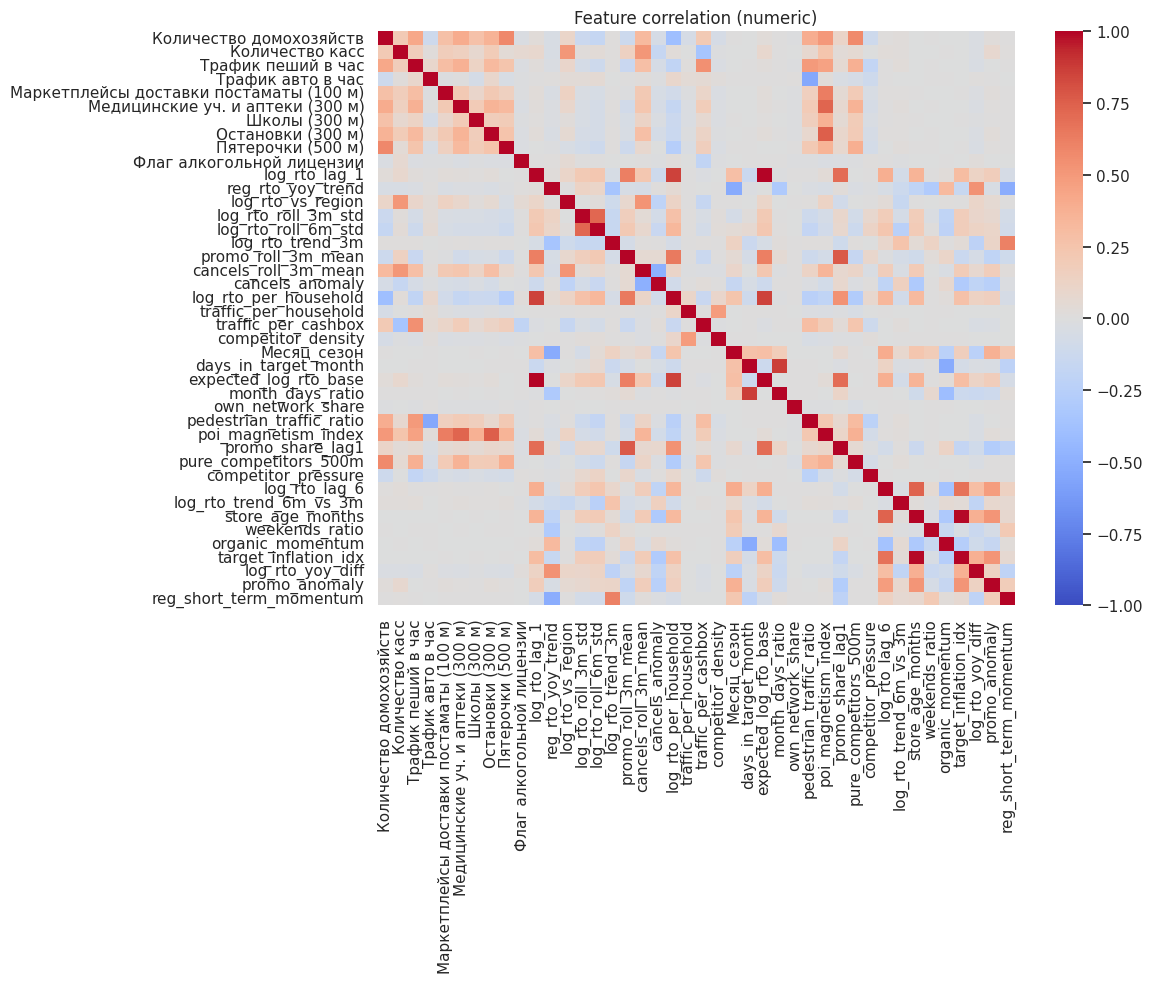

,feature_1,feature_2,corr
0,log_rto_lag_1,expected_log_rto_base,0.999912
1,store_age_months,target_inflation_idx,0.990546
2,days_in_target_month,month_days_ratio,0.867395
3,log_rto_lag_1,log_rto_per_household,0.857630
4,log_rto_per_household,expected_log_rto_base,0.857530
5,promo_roll_3m_mean,promo_share_lag1,0.768413
6,Остановки (300 м),poi_magnetism_index,0.752129
7,log_rto_lag_6,store_age_months,0.735532
8,Медицинские уч. и аптеки (300 м),poi_magnetism_index,0.730908
9,log_rto_roll_3m_std,log_rto_roll_6m_std,0.720876


In [106]:
top_best_pairs = analyze_feature_correlation(
    df=master_df[best_ts_features], 
    exclude_cols=[], 
    top_n_pairs=25,
    figsize=(12, 10)
)
display(top_best_pairs)

# Test pipeline

In [107]:
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

def run_cv(master_df, val_cnt, time_ids, cat_features, drop_cols, model_params, use_inflation=False, inflation_dict=None):
    val_time_ids = time_ids[-val_cnt:]
    
    fold_scores = []
    models = []
    
    for val_time in val_time_ids:
        print(f"Валидация на месяце: {val_time}")
        
        train_df = master_df[master_df['time_id'] < val_time].copy()
        val_df = master_df[master_df['time_id'] == val_time].copy()
        
        X_train, y_train_raw = train_df.drop(columns=drop_cols), train_df['РТО']
        X_val, y_val_raw = val_df.drop(columns=drop_cols), val_df['РТО']
        
        y_train_log = np.log1p(y_train_raw)
        y_val_log = np.log1p(y_val_raw)
        
        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        
        model = CatBoostRegressor(**model_params)
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        preds_log = model.predict(X_val)
        preds_raw = np.expm1(preds_log)
    
        if use_inflation and inflation_dict is not None:
            val_year, val_month = int(val_time) // 100, int(val_time) % 100
            val_macro_idx = inflation_dict[(val_year, val_month)]
            preds_final = preds_raw * val_macro_idx
            best_mape = mean_absolute_percentage_error(val_df['РТО_nominal'], preds_final)
        else:
            best_mape = mean_absolute_percentage_error(y_val_raw, preds_raw)
        
        fold_scores.append(best_mape)
        models.append(model)
        
        print(f"MAPE для {val_time}: {best_mape * 100:.3f}%\n")
    
    mean_mape = np.mean(fold_scores) * 100
    std_mape = np.std(fold_scores) * 100
    
    print(f"Средний MAPE по всем фолдам: {mean_mape:.3f}% ± {std_mape:.3f}%")
    
    return models, fold_scores

In [108]:
time_ids = sorted(master_df['time_id'].unique())
len(time_ids)

26

## Старый + base_df['expected_log_rto_base']

In [ ]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202411
0:	learn: 0.4590593	test: 0.4585246	best: 0.4585246 (0)	total: 34.9ms	remaining: 1m 44s
500:	learn: 0.0957159	test: 0.0602738	best: 0.0602413 (485)	total: 13.2s	remaining: 1m 5s
1000:	learn: 0.0917787	test: 0.0591356	best: 0.0591099 (967)	total: 26.8s	remaining: 53.5s
1500:	learn: 0.0900648	test: 0.0586493	best: 0.0586181 (1469)	total: 40.5s	remaining: 40.4s
2000:	learn: 0.0886940	test: 0.0583715	best: 0.0583657 (1995)	total: 54.3s	remaining: 27.1s
2500:	learn: 0.0875198	test: 0.0581244	best: 0.0581229 (2493)	total: 1m 8s	remaining: 13.7s
2999:	learn: 0.0864382	test: 0.0579570	best: 0.0579535 (2984)	total: 1m 22s	remaining: 0us
bestTest = 0.05795348057
bestIteration = 2984
Shrink model to first 2985 iterations.
MAPE для 202411: 3.837%

Валидация на месяце: 202412
0:	learn: 0.4590203	test: 0.4993106	best: 0.4993106 (0)	total: 36.8ms	remaining: 1m 50s
500:	learn: 0.0943022	test: 0.0704300	best: 0.0704300 (500)	total: 13.6s	remaining: 1m 8s
1000:	learn: 0.09056

In [47]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=len(time_ids)//2,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202402
0:	learn: 0.4583658	test: 0.4535616	best: 0.4535616 (0)	total: 26.5ms	remaining: 1m 19s
bestTest = 0.1030657057
bestIteration = 186
Shrink model to first 187 iterations.
MAPE для 202402: 6.825%

Валидация на месяце: 202403
0:	learn: 0.4580178	test: 0.4695924	best: 0.4695924 (0)	total: 18.3ms	remaining: 54.8s
500:	learn: 0.1074162	test: 0.0732139	best: 0.0732139 (500)	total: 9.86s	remaining: 49.2s
1000:	learn: 0.1030463	test: 0.0726534	best: 0.0726509 (990)	total: 20.1s	remaining: 40.1s
bestTest = 0.07264910332
bestIteration = 1012
Shrink model to first 1013 iterations.
MAPE для 202403: 4.289%

Валидация на месяце: 202404
0:	learn: 0.4586159	test: 0.4591897	best: 0.4591897 (0)	total: 29ms	remaining: 1m 26s
500:	learn: 0.1054204	test: 0.0838136	best: 0.0838119 (499)	total: 10.2s	remaining: 51.1s
1000:	learn: 0.1011220	test: 0.0831375	best: 0.0831283 (998)	total: 20.9s	remaining: 41.8s
1500:	learn: 0.0989938	test: 0.0829035	best: 0.0829035 (1500)	total: 31.8s	r

## Новые фичи без отбора

In [82]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=len(time_ids)//2,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202402
0:	learn: 0.4583136	test: 0.4535762	best: 0.4535762 (0)	total: 30.5ms	remaining: 1m 31s
bestTest = 0.1037207355
bestIteration = 176
Shrink model to first 177 iterations.
MAPE для 202402: 6.883%

Валидация на месяце: 202403
0:	learn: 0.4579699	test: 0.4696556	best: 0.4696556 (0)	total: 31ms	remaining: 1m 32s
500:	learn: 0.1075415	test: 0.0739603	best: 0.0739603 (500)	total: 11.2s	remaining: 55.9s
1000:	learn: 0.1029581	test: 0.0729423	best: 0.0729423 (1000)	total: 22.7s	remaining: 45.3s
1500:	learn: 0.1007093	test: 0.0725454	best: 0.0724831 (1443)	total: 34.5s	remaining: 34.5s
bestTest = 0.07248313912
bestIteration = 1443
Shrink model to first 1444 iterations.
MAPE для 202403: 4.305%

Валидация на месяце: 202404
0:	learn: 0.4587173	test: 0.4593174	best: 0.4593174 (0)	total: 32.2ms	remaining: 1m 36s
500:	learn: 0.1053932	test: 0.0857322	best: 0.0857322 (500)	total: 11.9s	remaining: 59.3s
1000:	learn: 0.1008893	test: 0.0852444	best: 0.0852444 (1000)	total: 24s	

## Новые фичи с отбором

In [72]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=len(time_ids)//2,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202402
0:	learn: 0.4583130	test: 0.4535782	best: 0.4535782 (0)	total: 29.7ms	remaining: 1m 29s
bestTest = 0.1082372709
bestIteration = 140
Shrink model to first 141 iterations.
MAPE для 202402: 7.072%

Валидация на месяце: 202403
0:	learn: 0.4579738	test: 0.4696549	best: 0.4696549 (0)	total: 31.2ms	remaining: 1m 33s
500:	learn: 0.1075810	test: 0.0739872	best: 0.0739811 (498)	total: 10.9s	remaining: 54.6s
1000:	learn: 0.1029726	test: 0.0727422	best: 0.0727137 (977)	total: 22.4s	remaining: 44.8s
1500:	learn: 0.1006934	test: 0.0726986	best: 0.0725861 (1410)	total: 34.4s	remaining: 34.3s
bestTest = 0.0725861232
bestIteration = 1410
Shrink model to first 1411 iterations.
MAPE для 202403: 4.293%

Валидация на месяце: 202404
0:	learn: 0.4587173	test: 0.4593174	best: 0.4593174 (0)	total: 31.2ms	remaining: 1m 33s
500:	learn: 0.1054576	test: 0.0850906	best: 0.0850880 (483)	total: 11.8s	remaining: 58.6s
1000:	learn: 0.1009625	test: 0.0846399	best: 0.0846356 (920)	total: 23.9s

## Старый + base_df['expected_log_rto_base'] + FS

In [ ]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=len(time_ids)//2,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202402
0:	learn: 0.4585331	test: 0.4536075	best: 0.4536075 (0)	total: 31.4ms	remaining: 1m 34s
500:	learn: 0.1095125	test: 0.1030020	best: 0.0987228 (218)	total: 9.74s	remaining: 48.6s
bestTest = 0.09872275758
bestIteration = 218
Shrink model to first 219 iterations.
MAPE для 202402: 6.320%

Валидация на месяце: 202403
0:	learn: 0.4581571	test: 0.4699212	best: 0.4699212 (0)	total: 21.3ms	remaining: 1m 3s
500:	learn: 0.1077006	test: 0.0953662	best: 0.0950841 (480)	total: 9.69s	remaining: 48.3s
1000:	learn: 0.1029760	test: 0.0951426	best: 0.0947587 (765)	total: 19.8s	remaining: 39.4s
bestTest = 0.09475869643
bestIteration = 765
Shrink model to first 766 iterations.
MAPE для 202403: 7.115%

Валидация на месяце: 202404
0:	learn: 0.4588014	test: 0.4591577	best: 0.4591577 (0)	total: 28.3ms	remaining: 1m 24s
500:	learn: 0.1056259	test: 0.0839257	best: 0.0839257 (500)	total: 10.2s	remaining: 50.7s
1000:	learn: 0.1009474	test: 0.0827964	best: 0.0827964 (1000)	total: 20.5s	r

## Старый без base_df['expected_log_rto_base']

In [38]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=len(time_ids)//2,
    time_ids=time_ids, #TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202402
0:	learn: 0.4585331	test: 0.4536075	best: 0.4536075 (0)	total: 31.3ms	remaining: 1m 33s
500:	learn: 0.1095124	test: 0.1030029	best: 0.0987230 (218)	total: 9.43s	remaining: 47s
bestTest = 0.09872304753
bestIteration = 218
Shrink model to first 219 iterations.
MAPE для 202402: 6.320%

Валидация на месяце: 202403
0:	learn: 0.4581571	test: 0.4699212	best: 0.4699212 (0)	total: 21.2ms	remaining: 1m 3s
500:	learn: 0.1077004	test: 0.0953668	best: 0.0950847 (480)	total: 9.49s	remaining: 47.4s
1000:	learn: 0.1028709	test: 0.0945023	best: 0.0943671 (871)	total: 19.5s	remaining: 38.9s
bestTest = 0.09433890601
bestIteration = 1170
Shrink model to first 1171 iterations.
MAPE для 202403: 7.094%

Валидация на месяце: 202404
0:	learn: 0.4588014	test: 0.4591577	best: 0.4591577 (0)	total: 20.2ms	remaining: 1m
500:	learn: 0.1056259	test: 0.0839258	best: 0.0839258 (500)	total: 9.99s	remaining: 49.8s
1000:	learn: 0.1009708	test: 0.0828105	best: 0.0828105 (1000)	total: 20.2s	remai

In [180]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU',
    # 'thread_count': -1
}

models_base, scores_base = run_cv(
    master_df=master_df,
    val_cnt=4,
    time_ids=TS_VAL_FOLDS,
    cat_features=cat_features,
    drop_cols=DROP_COLS,#
    model_params=cb_params,
    use_inflation=False
)

Валидация на месяце: 202403
0:	learn: 0.4579422	test: 0.4693990	best: 0.4693990 (0)	total: 30.6ms	remaining: 1m 31s
500:	learn: 0.1076659	test: 0.0747278	best: 0.0747278 (500)	total: 10.9s	remaining: 54.4s
1000:	learn: 0.1028741	test: 0.0733524	best: 0.0733497 (997)	total: 22.3s	remaining: 44.6s
1500:	learn: 0.1008947	test: 0.0732233	best: 0.0731376 (1410)	total: 34.1s	remaining: 34s
bestTest = 0.07313755771
bestIteration = 1410
Shrink model to first 1411 iterations.
MAPE для 202403: 4.442%

Валидация на месяце: 202409
0:	learn: 0.4597447	test: 0.4497358	best: 0.4497358 (0)	total: 36.8ms	remaining: 1m 50s
500:	learn: 0.0981855	test: 0.0822702	best: 0.0822158 (497)	total: 13.4s	remaining: 1m 7s
1000:	learn: 0.0937392	test: 0.0798240	best: 0.0798239 (999)	total: 27.5s	remaining: 54.8s
1500:	learn: 0.0918833	test: 0.0790844	best: 0.0790745 (1492)	total: 41.9s	remaining: 41.8s
2000:	learn: 0.0906165	test: 0.0788069	best: 0.0787871 (1977)	total: 56.5s	remaining: 28.2s
2500:	learn: 0.0894808

# 

# Optuna

In [184]:
import optuna
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
from catboost import CatBoostRegressor, Pool

def objective(trial):
    param = {
        'iterations': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_categorical('border_count', [128, 254]),
        
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'task_type': 'GPU',
        'random_seed': 42,
        'od_type': 'Iter',
        'od_wait': 300,
        'verbose': 0
    }

    fold_mapes = []
    
    for val_time in TS_VAL_FOLDS:
        train_df = master_df[master_df['time_id'] < val_time]
        val_df = master_df[master_df['time_id'] == val_time]
        
        X_train = train_df[best_ts_features]
        y_train_log = np.log1p(train_df['РТО'])
        
        X_val = val_df[best_ts_features]
        y_val_log = np.log1p(val_df['РТО'])
        y_val_raw = val_df['РТО']
        
        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        
        model = CatBoostRegressor(**param)
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        preds_log = model.predict(X_val)
        preds_raw = np.expm1(preds_log)
        
        fold_mape = mean_absolute_percentage_error(y_val_raw, preds_raw)
        fold_mapes.append(fold_mape)
        
    return np.mean(fold_mapes) * 100

print("start Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("parameters")
print(f"Лучший MAPE: {study.best_value:.4f}%")
for key, value in study.best_params.items():
    print(f"'{key}': {value},")

[I 2026-05-26 20:22:16,662] A new study created in memory with name: no-name-a1084899-4557-41d7-85f5-cb43c6d81436


start Optuna...


[I 2026-05-26 20:31:41,091] Trial 0 finished with value: 4.463376750773289 and parameters: {'learning_rate': 0.015420125209995023, 'depth': 7, 'l2_leaf_reg': 7, 'random_strength': 0.0006066556501816909, 'bagging_temperature': 0.7628859915290735, 'border_count': 128}. Best is trial 0 with value: 4.463376750773289.
[I 2026-05-26 20:38:44,659] Trial 1 finished with value: 4.416536600287663 and parameters: {'learning_rate': 0.021617258273793988, 'depth': 6, 'l2_leaf_reg': 10, 'random_strength': 7.319018034349527e-05, 'bagging_temperature': 0.037999681020670084, 'border_count': 128}. Best is trial 1 with value: 4.416536600287663.
[I 2026-05-26 20:48:15,718] Trial 3 finished with value: 4.679084653644456 and parameters: {'learning_rate': 0.05249443125346663, 'depth': 4, 'l2_leaf_reg': 7, 'random_strength': 1.308445070023382, 'bagging_temperature': 0.13497976353529517, 'border_count': 254}. Best is trial 1 with value: 4.416536600287663.
[I 2026-05-26 20:56:34,806] Trial 4 finished with value:

KeyboardInterrupt: 

#

# Predict

In [185]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool


drop_cols = ['new_id', 'РТО', 'time_id']
# drop_cols = ['new_id', 'РТО', 'РТО_nominal', 'time_id']
# X_train_full = master_df.drop(columns=drop_cols)
# y_train_full_log = np.log1p(master_df['РТО'])
X_train_full = master_df[best_ts_features]
y_train_full_log = np.log1p(master_df['РТО'])
cat_features = [c for c in cat_features if c in best_ts_features]

full_train_pool = Pool(X_train_full, y_train_full_log, cat_features=cat_features)

final_model = CatBoostRegressor(
    iterations=4000, 
    learning_rate=0.021617258273793988,
    depth=6,
    loss_function='RMSE', #better optimaze MAPE 
    random_seed=42,
    verbose=500,
    l2_leaf_reg=10,
    task_type = "GPU",
    random_strength = 7.319018034349527e-05,
    bagging_temperature = 0.037999681020670084, 
    border_count= 128
    # thread_count = -1
)

final_model.fit(full_train_pool)

target_year = 2025 
target_month = 3   

test_df = create_features_for_month(df, target_year, target_month)

for col in cat_features:
    test_df[col] = test_df[col].fillna('Missing').astype(str)

submit_ids = test_df['new_id']

X_test = test_df[best_ts_features]

test_preds_log = final_model.predict(X_test)

# mar_2025_idx = inflation_dict[(2025, 3)]
# test_preds_raw = np.expm1(test_preds_log) * mar_2025_idx
test_preds_raw = np.expm1(test_preds_log)

submission = pd.DataFrame({
    'new_id': submit_ids,
    'rto': test_preds_raw
})

filename = f'submission1.csv'
submission.to_csv(filename, index=False)

'done'

0:	learn: 0.4636154	total: 42.7ms	remaining: 2m 50s
500:	learn: 0.0945833	total: 15.8s	remaining: 1m 50s
1000:	learn: 0.0897563	total: 32.1s	remaining: 1m 36s
1500:	learn: 0.0875283	total: 48.7s	remaining: 1m 21s
2000:	learn: 0.0862463	total: 1m 5s	remaining: 1m 5s
2500:	learn: 0.0854151	total: 1m 22s	remaining: 49.5s
3000:	learn: 0.0847703	total: 1m 39s	remaining: 33.2s
3500:	learn: 0.0842216	total: 1m 56s	remaining: 16.7s
3999:	learn: 0.0836960	total: 2m 14s	remaining: 0us


'done'

Вычисляем SHAP values...

Топ фич по версии SHAP:


,Feature,Mean_Absolute_SHAP
8,expected_log_rto_base,0.219641
4,log_rto_lag_1,0.058647
5,log_rto_vs_region,0.046216
10,Регион_Площадь,0.037228
7,Месяц_сезон,0.030084
2,Количество касс,0.023435
0,Регион,0.012698
3,Регион_Город,0.009324
17,month_days_ratio,0.007892
15,log_rto_momentum,0.006576


/tmp/ipykernel_1082/1359179928.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


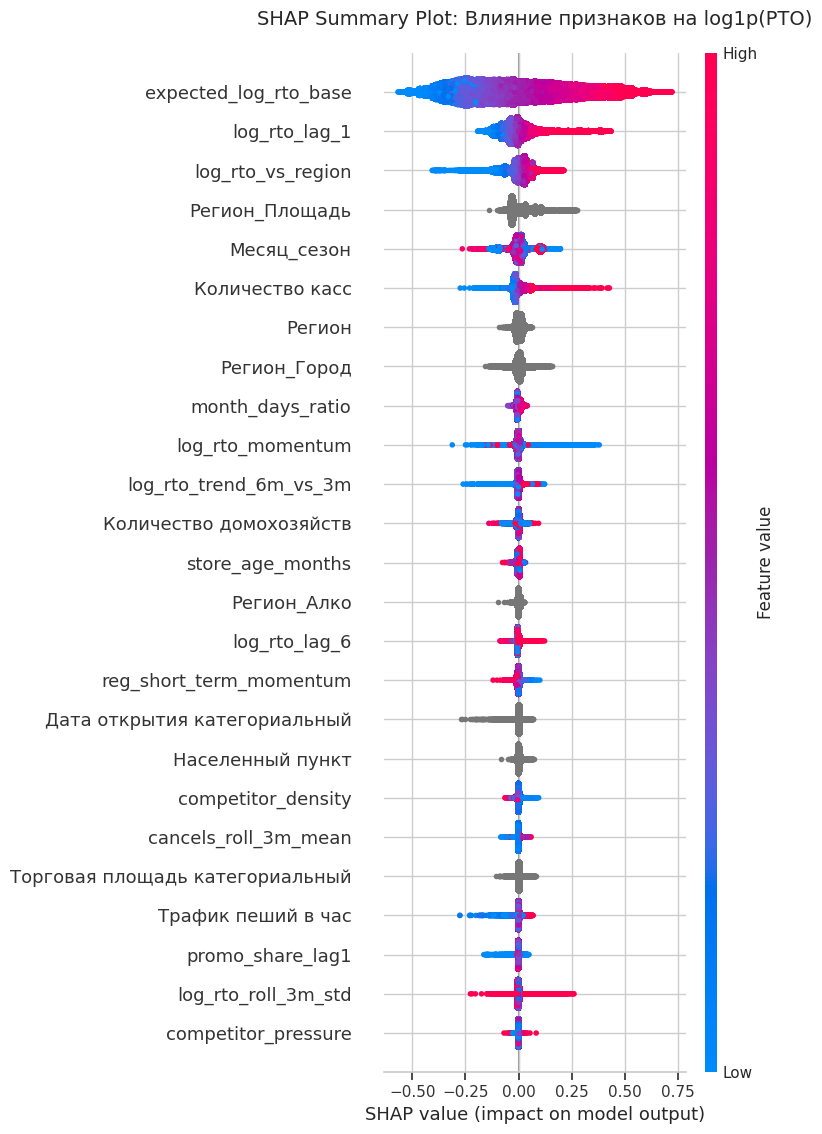

In [21]:
import shap
import matplotlib.pyplot as plt

print("Вычисляем SHAP values...")
shap_results = final_model.get_feature_importance(full_train_pool, type='ShapValues')

shap_values = shap_results[:, :-1]
base_value = shap_results[0, -1]

shap_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Mean_Absolute_SHAP': np.mean(np.abs(shap_values), axis=0)
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)

print("\nТоп фич по версии SHAP:")
display(shap_importance.head(25))

plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values, 
    X_train_full, 
    max_display=25, 
    plot_type="dot", 
    show=False
)

plt.title("SHAP Summary Plot: Влияние признаков на log1p(РТО)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

In [16]:
importance = final_model.get_feature_importance()

feature_importances = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
feature_importances

,Feature,Importance
13,log_rto_lag_1_per_day,40.640616
14,expected_log_rto_base,27.069609
19,Месяц_сезон,8.231218
15,Регион_Площадь,4.625541
6,log_rto_vs_region,4.421555
2,Количество касс,3.052505
4,log_rto_lag_1,1.594136
11,log_rto_momentum,1.351553
3,Регион_Город,1.225034
8,log_rto_roll_3m_max,1.099416
